# Deterministic Mathematical Optimization

# Table of Contents

### 1. Linear Programming with Gurobi
* **1.1** Solving an LP with Gurobi
* **1.2** We can plot the feasible region too (just for fun)

### 2. Duality
* **2.1** Primals and Duals
* **2.2** In General
* **2.3** How to solve the duals in Gurobi
* **2.4** Weak Duality
* **2.5** Strong Duality

### 3. Mathematical Formulation
* **3.1** First-Stage Problem
* **3.2** Second-Stage Problem

### 4. Recourse

### 5. Deterministic Equivalent Problem
* **5.1** Solving a Two-Stage Problem Using the Deterministic Equivalent
* **5.2** The Farmers Problem
* **5.3** Defining The Farmers Problem
* **5.4** Solving the Farmers Problem
* **5.5** Compact Problem Formulation

### 6. Benders Decomposition



 # ------------------------------------------------------------------------------

# 1. Linear Programming with Gurobi

 ## 1.1 Solving a LP with Gurobi

In [1]:
# imports init
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt 
import numpy as np

Consider the folowing Lp:
$$
\begin{align*}
\max \quad & z = 5x_1 + 4x_2 \\
\text{s.t.} \quad 
& x_1 \leq 4 \\
& x_1 + 2x_2 \leq 10 \\
& 3x_1+ 2x_2 \leq 16 \\
& x_1,x_2 \geq 0. 
\end{align*}
$$

We can solve this problem uing the Gurobi Library

In [2]:
# first we Initialise the probelm
model = gp.Model("LP_one")
    
#This get rid of the clutter in the terrminal
model.params.OutputFlag = 0
    
#next we create the decision variables, lb = 0 sets non negativity constraint, vtype=GRB.CONTINUOUS means x1,x2 can take on ay real value
x1 = model.addVar(lb = 0, vtype=GRB.CONTINUOUS, name = "x1")
x2 = model.addVar(lb = 0, vtype=GRB.CONTINUOUS, name = "x2")
    
#set the objective function
model.setObjective(5*x1 +4*x2, GRB.MAXIMIZE)
    
#add the constraints
c1 = model.addConstr(x1 <=4, name = "c1")
c2 = model.addConstr(x1 +2*x2 <= 10 ,name = "c2")
c3 = model.addConstr(3*x1+2*x2 <=16, name = "c3")
    
#optimise the model 
model.optimize()
    
if model.Status == GRB.OPTIMAL:
    print("\n--- Optimal Solution Found ---")
    print(f"x1 = {x1.X}, x2 = {x2.X}, Max z = {model.ObjVal}\n")
else:
    print("Optimal solution was not found.")

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2845539
Academic license 2845539 - for non-commercial use only - registered to rp___@soton.ac.uk

--- Optimal Solution Found ---
x1 = 3.0, x2 = 3.5, Max z = 29.0



## 1.2 We can plot the feasiable region in too (just for fun)

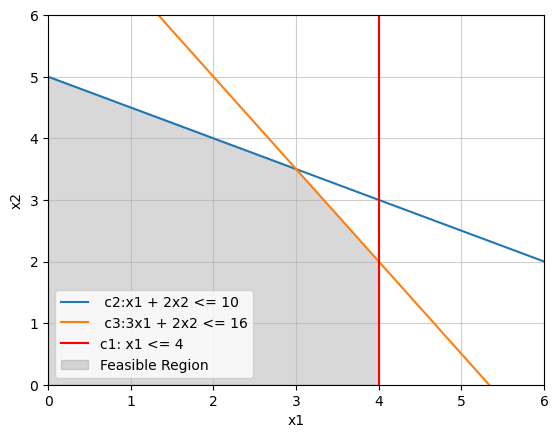

In [3]:
x1 = np.linspace(0,8,9)
c2 = -x1/2 +5
c3 = (-3/2)*x1 +8
plt.plot(x1,c2,label=" c2:x1 + 2x2 <= 10" )
plt.plot(x1,c3,label=" c3:3x1 + 2x2 <= 16" )
plt.axvline(x=4, color="red", label="c1: x1 <= 4")

feasible_upper_bound = np.minimum(c2, c3)
plt.fill_between(x1,0,feasible_upper_bound,where=(x1 <= 4) & (feasible_upper_bound >= 0),color="gray",alpha=0.3,label="Feasible Region",)

plt.xlabel("x1")
plt.xlim(0,6)
plt.ylabel("x2")
plt.ylim(0,6)
plt.legend()
plt.grid(True,alpha = 0.6)

# 2.Duality

## 2.1 Primals and Duals

Considering the same Lp:
$$
\begin{align*}
\max \quad & z = 5x_1 + 4x_2 \\
\text{s.t.} \quad 
& x_1 \leq 4 \\
& x_1 + 2x_2 \leq 10 \\
& 3x_1+ 2x_2 \leq 16 \\
& x_1,x_2 \geq 0. 
\end{align*}
$$

This is known as the **Primal**. In this primal, any valid choice of decison variables gives us a lower bound for a maximation problem. For example, let $x_1 = 1, x_2 = 1$, then: 
$$
\begin{align*}
\text{since } z &= 5x_1 + 4x_2 \\
z &= 5(1) + 4(1) = 9 \\
\implies z^* &\ge 9
\end{align*}
$$

We use Duality, to know how close we are to the least upperbound. 
To construct this upperbound, we take non negative multipliers $(y_1,y_2,y_3 \geq 0)$ and then scale each constrain and then sum them up.


$$
\begin{align*}
& y_1 x_1 \leq 4 y_1 \\
&y_2x_1 +2y_2x_2 \leq 10 y_2 \\
&3y_3x_1 +2y_3x_2 \leq 16y_3 \\
& \implies (y_1+y_2+3y_3)x_1 +(2y_2+2y_3)x_2 \leq 4y_1 +10y_2 +16y_3
\end{align*}
$$


The $4y_1 + 10y_2 + 16y_3$ is just a constant, so if we compare
$$ (y_1 + y_2 + 3y_3)x_1 + (2y_2 + 2y_3)x_2 \leq 4y_1 + 10y_2 + 16y_3 $$
to 
$$ z = 5x_1 + 4x_2 $$
then we need:
\begin{align*}
y_1 + y_2 + 3y_3 &\geq 5, \quad \text{and} \\
2y_2 + 2y_3 &\geq 4
\end{align*}
Putting it all together,
\begin{align*}
z = 5x_1 + 4x_2 &\leq (y_1+y_2+3y_3)x_1 + (2y_2+2y_3)x_2 \leq 4y_1 + 10y_2 + 16y_3 \\
\implies z &\leq 4y_1 + 10y_2 + 16y_3
\end{align*}

Therfore to get the least upper bound, we solve:
$$
\begin{align*}
\min \quad & w = 4y_1 + 10y_2 + 16y_3 \\
\text{s.t.} \quad 
&y_1 + y_2 + 3y_3 \geq 5 \\
&2y_2 + 2y_3 \geq 4 \\
&y_1,y_2,y_3 \geq 0
\end{align*}
$$
This is known as the **Dual**


### 2.2 In General

If our Primal is :

$$
\begin{align*}
\max \quad & z = c^Tx \\
\text{s.t.} \quad 
& Ax \leq b \\
& x \geq 0. 
\end{align*}
$$

Then our dual is

$$
\begin{align*}
\min \quad & w = b^Ty \\
\text{s.t.} \quad 
& A^Ty \geq c \\
& x \geq 0. 
\end{align*}
$$

Where: 
$$\begin{align}
    x & \text{: is the decisicion variable vector,} \\
    c & \text{: is the cost matrix} \\
    A & \text{: is the decion variable coeffient matrix}\\ 
    b & \text{: is the resource vector}\\
    y & \text{: is the dual variable vector}
\end{align}
$$
       

## 2.3 How to solve the duals in Gurobi

Code, to code for the exact values of the dual given the same primal in the start

In [4]:
# first we Initialise the probelm
model = gp.Model("LP_one")

#This get rid of the clutter in the terrminal
model.params.OutputFlag = 0

#next we create the decision variables, lb = 0 sets non negativity constraint, vtype=GRB.CONTINUOUS means x1,x2 can take on ay real value
x1 = model.addVar(lb = 0, vtype=GRB.CONTINUOUS, name = "x1")
x2 = model.addVar(lb = 0, vtype=GRB.CONTINUOUS, name = "x2")

#set the objective function
model.setObjective(5*x1 +4*x2, GRB.MAXIMIZE)

#add the constraints
c1 = model.addConstr(x1 <=4, name = "c1")
c2 = model.addConstr(x1 +2*x2 <= 10 ,name = "c2")
c3 = model.addConstr(3*x1+2*x2 <=16, name = "c3")

#optimise the model 
model.optimize()

if model.Status == GRB.OPTIMAL:
    print("\n--- Optimal Solution Found ---")
    print(f"x1 = {x1.X}, x2 = {x2.X}, Max z = {model.ObjVal}\n")
    print("--- Dual Values---")
    
    # Use .Pi to get the dual value of each specific constraint
    print(f"Dual Value for x1 <= 4      : {c1.Pi}")
    print(f"Dual Value for x1 + 2x2 <= 10: {c2.Pi}")
    print(f"Dual Value for 3x1 + 2x2 <= 16: {c3.Pi}")
else:
    print("Optimal solution was not found.")



--- Optimal Solution Found ---
x1 = 3.0, x2 = 3.5, Max z = 29.0

--- Dual Values---
Dual Value for x1 <= 4      : 0.0
Dual Value for x1 + 2x2 <= 10: 0.5
Dual Value for 3x1 + 2x2 <= 16: 1.5


## 2.4 Weak Duality

### Weak Duality Theorem

For any feasible solutions $x$  and $y$ , the following inequality holds:
$$c^T x \le b^T y$$

**Implications:**
* If the primal problem is unbounded, then the dual problem is infeasible.
* If the dual problem is unbounded, then the primal problem is infeasible.

### Proof
$$\begin{align*} c^T x &\leq (A^T y)^T x && (\text{since } A^T y \geq c \text{ and } x \geq 0) \\ &= y^T A x && (\text{using matrix transpose rules } (AB)^T = B^TA^T) \\ &\leq y^T b && (\text{since } A x \leq b \text{ and } y \geq 0) \\ &= b^T y && (\text{since } y^T b \text{ is a scalar, } y^T b = (y^T b)^T = b^T y) \end{align*}$$
$$\text{Since } c^T x \le b^T y \text{ for any primal feasible } x \text{ and dual feasible } y \text{, the optimal primal value is bounded above by the optimal dual value.}$$

## 2.5 Strong Duality

### Stong Duality Theorem

Optimal Feasible solutions satisfy $$c^T x = b^T y$$

### Proof
Let $x^*$ be an optimal solution to the Primal LP:$$\text{Maximize } c^T x \quad \text{s.t.} \quad A x \leq b, \; x \geq 0$$By Farkas' Lemma, if $x^*$ is optimal, there exist dual multipliers $y^* \geq 0$ and $s^* \geq 0$ s.t the optimality condition holds:$$\begin{align*} A^T y^* - s^* &= c && (\text{Dual feasibility requirement}) \\ y^* \geq 0, \; s^* &\geq 0 && (\text{Dual non-negativity}) \\ (b - A x^*)^T y^* &= 0 && (\text{Complementary slackness for } A x^* \leq b) \\ (x^*)^T s^* &= 0 && (\text{Complementary slackness for } x^* \geq 0) \end{align*}$$ Evaluate the optimal primal objective value $c^T x^*$:$$\begin{align*} c^T x^* &= (A^T y^* - s^*)^T x^* && (\text{substitute } c = A^T y^* - s^*) \\ &= ((A^T y^*)^T - (s^*)^T) x^* && (\text{distribute transpose: } (U - V)^T = U^T - V^T) \\ &= (y^*)^T A x^* - (s^*)^T x^* && (\text{apply matrix transpose rule } (A^T y^*)^T = (y^*)^T A) \\ &= (y^*)^T A x^* - 0 && (\text{since } (s^*)^T x^* = 0 \text{ by complementary slackness}) \\ &= (y^*)^T A x^* + (y^*)^T (b - A x^*) && (\text{add } 0 \text{ since } (y^*)^T(b - Ax^*) = 0 \text{ by complementary slackness}) \\ &= (y^*)^T A x^* + (y^*)^T b - (y^*)^T A x^* &&  \\ &= (y^*)^T b &&  \\ &= b^T y^* && (\text{since } (y^*)^T b \text{ is a scalar, } (y^*)^T b = b^T y^*) \end{align*}
$$Since $y^* \geq 0$ and $A^T y^* = c + s^* \geq c$, $y^*$ is a feasible solution to the Dual problem. Thus, the optimal value of the primal objective equals the optimal value of the dual objective.

# 3 Mathematical Formulation

## 3.1 First-Stage Problem

In the first stage, decisions are made under uncertainty.

\begin{align*}
    \min_{x} \quad & c^T x + \mathbb{E}_{\xi}[Q(x, \xi)] \\
    \text{s.t.} \quad & A x \ge b \\
    & x \ge 0
\end{align*}


Where: 
$$\begin{align}
    &x  \text{: is the First-stage decision variable vector,} \\
    &c^Tx  \text{: cost incurred in the first stage} \\
    & {\mathbb{E}_{\xi}[Q(x, \xi)] } \text{: Expected cost of the optimal recourse action taken in the second stage across all possible scenarios }\\ 
    &Ax \ge b, \, x \ge 0  \text{: Deterministic constraints governing the first-stage decisions}\\
\end{align}
$$

## 3.2 Second-Stage Problem
Once the random outcome is observed, a corrective recourse action $y$ is taken.
\begin{align*}
    Q(x, \xi) = \min_{y} \quad & q^T y \\
    \text{s.t.} \quad & W y \ge h - T x \\
    & y \ge 0
\end{align*}

Where: 
$$\begin{align}
    &y  \text{: is the Second-stage decision variable vector,} \\
    &Q(x, \xi)  \text{:  function representing the optimal second-stage cost for a given first-stage decision} \\
    & {\mathbb{E}_{\xi}[Q(x, \xi)] } \text{: Expected cost of the optimal recourse action taken in the second stage across all possible scenarios }\\ 
    &W y \ge h - T x  \text{: Recourse constraint linking the first-stage choice to second-stage feasibility.}\\
\end{align}
$$

# 4 Recourse

In stochastic programming, recourse simply means your ability to take a  corrective action after the random event happens.

## 4.1 Simple Recourse

In simple recourse, the recourse decision variable $y$ is split into two non-negative slack variables: $y_s^+$ (shortage) and $y_s^-$ (surplus).

The recourse matrix $W$ is strictly composed of Identity matrices: $W = [I, -I]$.The second-stage problem simplifies beautifully to:$$\min \quad \sum_{s \in \mathcal{S}} p_s (q^+ y_s^+ + q^- y_s^-)$$Subject to:$$y_s^+ - y_s^- = h_s - T_s x, \quad \forall s \in \mathcal{S}$$$$y_s^+, y_s^- \ge 0$$Here, $q^+$ is the unit penalty for falling short, and $q^-$ is the unit penalty (or negative reward) for going over.


## 4.2 Complete Recourse

Complete recourse means that the recourse matrix $W$ can map to any possible right-hand side vector. For any possible discrepancy vector $z = h_s - T_s x \in \mathbb{R}^m$, there exists a feasible recourse action $y \ge 0$ such that:$$W y = z$$In linear algebra terms, this means the positive span of the columns of $W$ covers the entire space $\mathbb{R}^m$.

## 4.3 Fixed Recourse 

A general two-stage stochastic program, the recourse constraint is written as $T_s x + W_s y_s = h_s$.If the problem has fixed recourse, the matrix $W_s$ drops the $s$ subscript because it is identical for all $s \in \mathcal{S}$. The constraint is formulated as:$$W y_s = h_s - T_s x, \quad \forall s \in \mathcal{S}$$

# 5 Deterministic Equivalent Problem

When the random vector $\xi$ follows a discrete distribution with a finite set of scenarios $S = \{1, \dots, S\}$, where each scenario $s$ occurs with probability $p_s$ s.t $\sum_{s=1}^S p_s = 1$, the problem can be reformulated into a deterministic equivalent problem:

\begin{align*}
    \min_{x, y_1, \dots, y_S} \quad & c^T x + \sum_{s=1}^S p_s \left(q_s^T y_s \right) \\
    \text{s.t.} \quad & A x \ge b \\
    & T_s x + W_s y_s \ge h_s, \quad \forall s \in \{1, \dots, S\} \\
    & x \ge 0, \quad y_s \ge 0, \quad \, \forall s \in \{1, \dots, S\}
\end{align*}

## 5.1 Solving a Two-stage problem using the Deterministic Equivalent

In [5]:
class Scenario:
    # a data contianer for the second stage scenarios
    def __init__(self, prob: float, q, h, T, W):
        self.prob = float(prob)
        self.q = np.asarray(q, dtype=float)
        self.h = np.asarray(h, dtype=float)
        self.T = np.asarray(T, dtype=float)
        self.W = np.asarray(W, dtype=float)

def solve_deterministic_equivalent(c, A_ub, b_ub, scenarios):
        model = gp.Model("deterministic_equivalent")
        model.Params.OutputFlag = 0

        c = np.asarray(c, dtype=float)

        # first-stage decision variables
        x = model.addMVar(shape=len(c), lb=0.0, name="x")

        # first-stage constraints
        if A_ub is not None:
            model.addConstr(np.asarray(A_ub, dtype=float) @ x <= np.asarray(b_ub, dtype=float), name="ub_constr")

        # second-stage decision variables and constraints
        y_vars = []
        expected_recourse_cost = 0

        for i, s in enumerate(scenarios):
            y = model.addMVar(shape=len(s.q), lb=0.0, name=f"y_{i}")
            y_vars.append(y)

            # constraint: W @ y >= h - T @ x  (Standardized to inequality)
            model.addConstr(s.W @ y >= s.h - s.T @ x, name=f"recourse_{i}")

            # accumulate objective
            expected_recourse_cost += s.prob * (s.q @ y)

        model.setObjective(c @ x + expected_recourse_cost, GRB.MINIMIZE)
        model.optimize()

        if model.Status == GRB.OPTIMAL:
            return {
                "status": "optimal",
                "optimal_cost": model.ObjVal,
                "x": x.X,
                "y": [y_var.X for y_var in y_vars]
            }
        else:
            raise RuntimeError(f"Optimization failed. Gurobi status: {model.Status}")


## 5.2 The Farmers Problem

The Farmer's Problem (from Birge & Louveaux) is a foundational example of decision making under uncertainty. A European farmer has 500 acres of land and must decide how to divide it among three crops: wheat, corb, and sugar beets. 

**First Stage**
*   How many acres should the farmer plant for each crop? 
*   Constraint: This decision must be made in the spring, before the weather and therefore the harvest yield is known.

**The Uncertainty**
*   Crop yields are dictated by the weather. 
*   There are three equally likely scenarios: Above Average, Average, and Below Average yields.

**Second Stage**
*   After the fall harvest, the farmer must meet strict cattle feed requirements (200 tons of wheat and 240 tons of corn).
*   If the harvest falls short, the farmer is forced to buy crops at a premium. 
*   If there is a surplus, the farmer can sell it for profit (sugar beets have a tiered pricing quota). 

**The Objective**
Find the initial land allocation that minimizes the total expected cost across all possible weather scenarios.

## 5.3 Defining The Farmers Problem

In [6]:
# first stage costs
c = [150, 230, 260]

# first stage constraint, total land <= 500 acres
A_ub = [[1.0, 1.0, 1.0]]
b_ub = [500.0]

# second stage variables y = [wheat sold, wheat bought, corn sold, corn bought, beets sold 36, beets sold 10]
# costs, negative means revenue, positive means cost
q_base = [-170.0, 238.0, -150.0, 210.0, -36.0, -10.0]

# second stage target values h
# [wheat demand, corn demand, beets minimum, beets constraint]
h_base = [200.0, 240.0, 0.0, -6000.0]

# recourse matrix W 
W_base = [
    [-1.0,  1.0,  0.0,  0.0,  0.0,  0.0],  # Wheat balance
    [ 0.0,  0.0, -1.0,  1.0,  0.0,  0.0],  # Corn balance
    [ 0.0,  0.0,  0.0,  0.0, -1.0, -1.0],  # Beets total yield balance
    [ 0.0,  0.0,  0.0,  0.0, -1.0,  0.0]   # Beets max quota sold at $36 (inequality requires negative)
]

# the 3 weather scenarios
yield_data = [
    {"name": "Above Average", "prob": 1/3, "w": 3.0, "c": 3.6, "b": 24.0},
    {"name": "Average",       "prob": 1/3, "w": 2.5, "c": 3.0, "b": 20.0},
    {"name": "Below Average", "prob": 1/3, "w": 2.0, "c": 2.4, "b": 16.0}
]

scenarios = []
for data in yield_data:
    # Technology matrix T, yields per acre for current scenario
    T_s = [
        [data["w"], 0.0,       0.0],       
        [0.0,       data["c"], 0.0],       
        [0.0,       0.0,       data["b"]], 
        [0.0,       0.0,       0.0]        
    ]
    scenarios.append(Scenario(data["prob"], q_base, h_base, T_s, W_base))

## 5.4 Solving the Farmers Problem

In [7]:
res = solve_deterministic_equivalent(c, A_ub, b_ub, scenarios)
x = res['x']

print(f"Overall Expected Profit: ${-res['optimal_cost']:,.0f}\n")
print(f"{'':<15} {'Wheat':<10} {'Corn':<10} {'Beets':<10}")
print("-" * 45)
print(f"{'Area (acres)':<15} {x[0]:<10.0f} {x[1]:<10.0f} {x[2]:<10.0f}\n")

for i, data in enumerate(yield_data):
    y = res['y'][i]
    s_name = data['name'].split()[0]
    
    y_w = x[0] * data['w']
    y_c = x[1] * data['c']
    y_b = x[2] * data['b']
    
    print(f"--- {s_name} Yield Scenario ---")
    print(f"{'Yield (T)':<15} {y_w:<10.0f} {y_c:<10.0f} {y_b:<10.0f}")
    print(f"{'Sales (T)':<15} {y[0]:<10.0f} {y[2]:<10.0f} {y[4]:<10.0f}")
    print(f"{'Purchases (T)':<15} {y[1]:<10.0f} {y[3]:<10.0f} {0:<10}\n")


Overall Expected Profit: $108,390

                Wheat      Corn       Beets     
---------------------------------------------
Area (acres)    170        80         250       

--- Above Yield Scenario ---
Yield (T)       510        288        6000      
Sales (T)       310        48         6000      
Purchases (T)   0          0          0         

--- Average Yield Scenario ---
Yield (T)       425        240        5000      
Sales (T)       225        0          5000      
Purchases (T)   0          0          0         

--- Below Yield Scenario ---
Yield (T)       340        192        4000      
Sales (T)       140        0          4000      
Purchases (T)   0          48         0         



## 5.5 Compact Problem Formulation

The deterministic equivalent problem can be written in a more compact block matrix form, with the constraint matrix D having a block angular structure:
\begin{align*}
    \min_{z} \quad & g^T z \\
    \text{s.t.} \quad & D z \ge r \\
    & z \ge 0
\end{align*}

where the variable vector $z$, the cost vector $g$, the RHS vecter $r$, and the constraint matrix $D$ are defined as:\begin{equation*}
    z = \begin{pmatrix} x \\ y_1 \\ y_2 \\ \vdots \\ y_S \end{pmatrix}, \quad
    g = \begin{pmatrix} c \\ p_1 q_1 \\ p_2 q_2 \\ \vdots \\ p_S q_S \end{pmatrix}, \quad
    r = \begin{pmatrix} b \\ h_1 \\ h_2 \\ \vdots \\ h_S \end{pmatrix}
\end{equation*}

\begin{equation*}
    D = \begin{pmatrix} 
    A & 0 & 0 & \dots & 0 \\ 
    T_1 & W_1 & 0 & \dots & 0 \\ 
    T_2 & 0 & W_2 & \dots & 0 \\ 
    \vdots & \vdots & \vdots & \ddots & \vdots \\ 
    T_S & 0 & 0 & \dots & W_S 
    \end{pmatrix}
\end{equation*}

Note: This stuctre is useful in the subproblem when implementing benders decomposition algorithm

# 6 Benders Decomposition

Because solving the deterministic equivalent problem directly can be highly computationally expensive for a large number of scenarios, we often rely on a more compact problem formulation using Benders Decomposition. Fundamentally, we set up a Master Problem and a  Subproblem. The master problem proposes a constant first-stage decision variable, $\bar{x}$. Fixing $x$ turns the second-stage into a standard linear program for each scenario $s$, and we solve for for $y_s$.

The general master Problem is:

\begin{align*}
    \min_{x, \theta} \quad & c^T x + \theta \\
    \text{s.t.} \quad & A x \ge b \\
    & x \ge 0 \\
    & \theta \geq L \\
    & \theta \geq \alpha_t + \beta_t^T x, \quad t = 1, \dots, \tau
\end{align*}

Where: 
$$\begin{align}
    &LB  \text{: is a vaid lower bound,} \\
    & \theta \text{:  is an approximation for: } Q(x)= \sum_{s=1}^{S} p_s v(\Xi^s,x)\\
    & \theta \geq \alpha_t + \beta_t^T x \text{: is an optimality cut}\\ 
\end{align}
$$

Insert Algorithmn for single and multi cut later

# 7 L-shaped Lagrangian  